In [1]:
import os
import shutil #moving and coping files
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

In [2]:
import kagglehub

path=kagglehub.dataset_download("jessicali9530/celeba-dataset")
print("Dataset download txt",path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Dataset download txt /kaggle/input/celeba-dataset


In [3]:
import os
import shutil #moving and coping files

#create a smaller Dataset (500 Images)
source_folder =os.path.join(path,"img_align_celeba","img_align_celeba")

destination_folder="celeda_small/faces"

os.makedirs(destination_folder,exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder,img),
        os.path.join(destination_folder,img),
    )
print("Copied",len(images),"images")

Copied 5000 images


In [4]:
#Data preprocessing
#changed batch size from 64 to 128
IMAGE_SIZE=(128,128)

BATCH_SIZE=64

In [5]:
datagen =ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2

)

In [6]:
#Load Dataset
train_generator =datagen.flow_from_directory(
    "celeda_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [7]:
validation_generator =datagen.flow_from_directory(
    "celeda_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


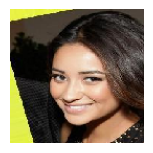

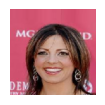

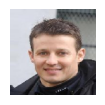

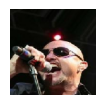

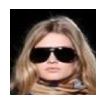

In [8]:
#Display Sample Images
images, _ =next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.show()

In [9]:
input_img =Input(shape=(128,128,3))
x=Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(input_img)
x=MaxPooling2D(
    (2,2),
    padding="same"
    )(x)
x=Conv2D(
    128,
    (3,3),
    activation="relu",
    padding="same"
)(x)
x=MaxPooling2D(
    (2,2),
    padding="same"
    )(x)
x=Conv2D(
    256,
    (3,3),
    activation="relu",
    padding="same"
)(x)
encoded=MaxPooling2D(
 (2,2),
 padding="same"
)(x)

In [10]:
x=Conv2D(
    256,
    (3,3),
    activation="relu",
    padding="same"
)(encoded)
x=UpSampling2D((2,2))(x)
x=Conv2D(
    128,
    (3,3),
    activation="relu",
    padding="same"
)(x)
x=UpSampling2D((2,2))(x)
x=Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(x)
x=UpSampling2D((2,2))(x)
decoded=Conv2D(
    3,
    (3,3),
    activation="sigmoid",
    padding="same"
)(x)

In [11]:
#create model
autoencoder=Model(
    input_img,
    decoded
)

In [12]:
#compie model
autoencoder.compile(optimizer="adam",loss="binary_crossentropy")

In [13]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,459 (5.08 MB)

 Trainable params: 1,331,459 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
#train model
history=autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - loss: 0.4783 - val_loss: 0.4781
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - loss: 0.4788 - val_loss: 0.4781
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - loss: 0.4789 - val_loss: 0.4789
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - loss: 0.4786 - val_loss: 0.4779
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - loss: 0.4775 - val_loss: 0.4776
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - loss: 0.4804 - val_loss: 0.4795
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - loss: 0.4778 - val_loss: 0.4780
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 184ms/step - loss: 0.4777 - val_loss: 0.4772
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 189ms/step - loss: 0.4769 - val_loss: 0.4769
Epoch 10/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 182ms/step - loss: 0.4768 - val_loss: 0.4774
Epoch 11/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - loss: 0.4772 - val_loss: 0.4777
Epoch 12/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11

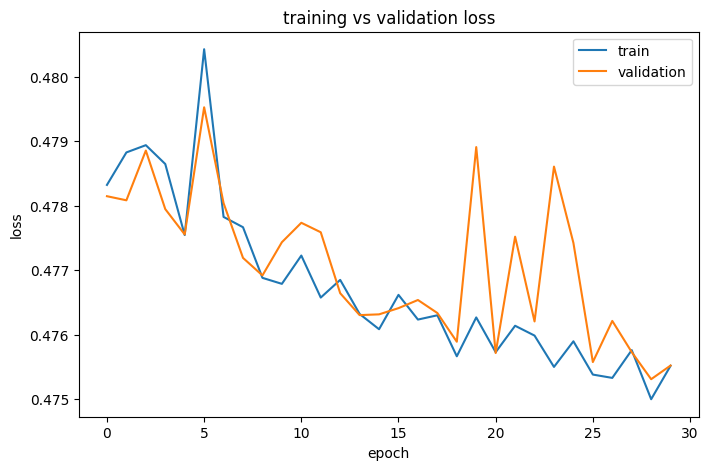

In [20]:
#plot loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('training vs validation loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'])
plt.show()

In [21]:
#evaluate model
loss=autoencoder.evaluate(validation_generator)
print("validation loss",loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.4755
validation loss 0.47551852464675903


In [22]:
#reconstruct images
images,_=next(validation_generator)
reconstructed_images=autoencoder.predict(images)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


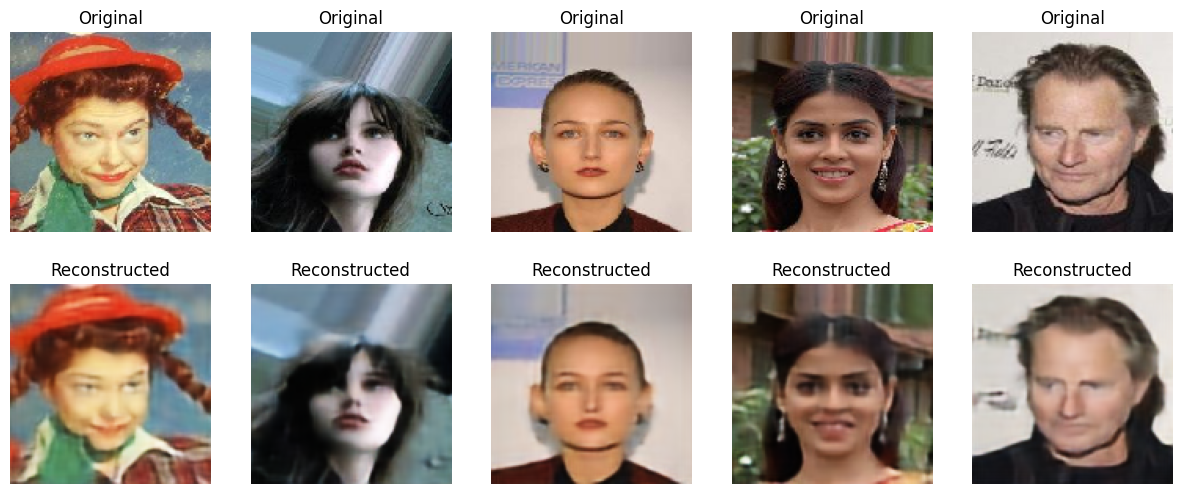

In [23]:
n=5
plt.figure(figsize=(15,6))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.title("Original")
  plt.axis("off")
  plt.subplot(2,n,i+n+1)
  plt.imshow(reconstructed_images[i])
  plt.title("Reconstructed")
  plt.axis("off")
plt.show()

